In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
%matplotlib inline

#read dataset into pandas dataframe
train_sales_df = pd.read_csv(r"C:\Users\s843971\Downloads\Big mart sales\train_sales.csv")

test_sales_df = pd.read_csv(r"C:\Users\s843971\Downloads\Big mart sales\test_sales.csv")

#concatenate train and test dataset so that we can perform feature engineering in one go on both datasets

sales_df = ([train_sales_df,test_sales_df])




In [2]:
train_sales_df.shape

(8523, 12)

In [34]:
train_sales_df.pivot_table(index='Outlet_Type',columns = 'Outlet_Size',values = 'Item_Identifier',aggfunc = 'count')

Outlet_Size,High,Medium,Small
Outlet_Type,,,
Grocery Store,NaN,NaN,528.0
Supermarket Type1,932.0,930.0,1860.0
Supermarket Type2,NaN,928.0,NaN
Supermarket Type3,NaN,935.0,NaN


In [3]:
from sklearn.model_selection import train_test_split

train_sales,test_sales = train_test_split(train_sales_df,test_size = 0.2,random_state = 42)



In [18]:
train_sales.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
549,FDW44,9.500,Regular,0.035206,Fruits and Vegetables,171.3448,OUT049,1999,Medium,Tier 1,Supermarket Type1,2386.2272
7757,NCF54,18.000,Low Fat,0.047473,Household,170.5422,OUT045,2002,NaN,Tier 2,Supermarket Type1,3103.9596
764,FDY03,17.600,Regular,0.076122,Meat,111.7202,OUT046,1997,Small,Tier 1,Supermarket Type1,1125.2020
6867,FDQ20,8.325,Low Fat,0.029845,Fruits and Vegetables,41.6138,OUT045,2002,NaN,Tier 2,Supermarket Type1,284.2966
2716,FDP34,12.850,Low Fat,0.137228,Snack Foods,155.5630,OUT046,1997,Small,Tier 1,Supermarket Type1,4224.5010


In [4]:
train_sales.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,5644.000000,6818.000000,6818.000000,6818.000000,6818.000000
mean,12.886347,0.066097,141.905134,1997.856850,2202.365231
std,4.644777,0.051429,62.547789,8.395692,1720.024464
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.880000,0.026939,94.175200,1987.000000,851.225300
50%,12.600000,0.054129,144.262800,1999.000000,1808.312800
75%,16.850000,0.094791,186.855600,2004.000000,3123.933600
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [20]:
pd.crosstab(train_sales_df.Outlet_Type,train_sales_df.Outlet_Size)

Outlet_Size,High,Medium,Small
Outlet_Type,,,
Grocery Store,0,0,528
Supermarket Type1,932,930,1860
Supermarket Type2,0,928,0
Supermarket Type3,0,935,0


In [7]:
#find out missing values from the dataset

train_sales.apply(lambda x: sum(x.isnull()))

Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  1935
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [6]:
mean_weight_by_type = train_sales.pivot_table(index='Item_Type',values = 'Item_Weight')

miss_bool = train_sales['Item_Weight'].isnull()

train_sales.loc[miss_bool,'Item_Weight'] = train_sales.loc[miss_bool,'Item_Type'].apply(lambda x :mean_weight_by_type.loc[x])



C:\Users\s843971\AppData\Local\Continuum\Anaconda3\lib\site-packages\pandas\core\indexing.py:517: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  self.obj[item] = s


In [ ]:
mean_weight_by_type = train_sales.pivot_table(index='Item_Type',values = 'Item_Weight')

miss_bool = train_sales['Item_Weight'].isnull()

train_sales.loc[miss_bool,'Item_Weight'] = train_sales.loc[miss_bool,'Item_Type'].apply(lambda x :mean_weight_by_type.loc[x])



In [11]:
train_sales['Outlet_Type'].value_counts()

train_sales.pivot_table(index='Outlet_Type',columns = 'Outlet_Size',values = 'Item_Identifier',aggfunc = 'count')

Outlet_Size,High,Medium,Small
Outlet_Type,,,
Grocery Store,NaN,NaN,413.0
Supermarket Type1,744.0,720.0,1493.0
Supermarket Type2,NaN,752.0,NaN
Supermarket Type3,NaN,761.0,NaN


In [19]:
train_sales.groupby('Outlet_Type')['Outlet_Size'].value_counts()

Outlet_Type        Outlet_Size
Grocery Store      Small           413
Supermarket Type1  Small          1493
                   High            744
                   Medium          720
Supermarket Type2  Medium          752
Supermarket Type3  Medium          761
Name: Outlet_Size, dtype: int64

In [18]:
miss_bool


0       False
1       False
2       False
3       False
4       False
5       False
6       False
7       False
8       False
9       False
10      False
11      False
12      False
13      False
14      False
15      False
16      False
17      False
18      False
19      False
20      False
21      False
22      False
23      False
24      False
25      False
26      False
27      False
28      False
29      False
        ...  
8493    False
8494    False
8495    False
8496    False
8497    False
8498    False
8499    False
8500    False
8501    False
8502    False
8503    False
8504    False
8505    False
8506    False
8507    False
8508    False
8509    False
8510    False
8511    False
8512    False
8513    False
8514    False
8515    False
8516    False
8517    False
8518    False
8519    False
8520    False
8521    False
8522    False
Name: Item_Weight, Length: 8523, dtype: bool

In [2]:
#imputing Item_weight missing values with mean value per Item_Identifier

#mean value of Item_weight per Item_identifer
mean_weight = train_sales_df.pivot_table(index = 'Item_Identifier', values = 'Item_Weight')

#cerating a boolean df for missing weights

miss_bool = train_sales_df['Item_Weight'].isnull()

#imputing the missing values for Item_Weight 
train_sales_df.loc[miss_bool,'Item_Weight'] = train_sales_df.loc[miss_bool,'Item_Identifier'].apply(lambda x:mean_weight.loc[x,:])





In [15]:
train_sales_df.pivot_table(index = 'Item_Fat_Content',values='Item_Weight',aggfunc=np.mean)

,Item_Weight
Item_Fat_Content,
LF,12.960237
Low Fat,12.975812
Regular,12.694633
low fat,12.599554
reg,13.004103


In [14]:
train_sales_df.loc[(train_sales_df['Item_Identifier'] == 'FDE52')]

train_sales_df.pivot_table(index = 'Item_Type',values='Item_Weight',aggfunc=np.mean)

,Item_Weight
Item_Type,
Baking Goods,12.285317
Breads,11.297689
Breakfast,12.779727
Canned,12.403320
Dairy,13.379905
Frozen Foods,12.782404
Fruits and Vegetables,13.236713
Hard Drinks,11.456238
Health and Hygiene,13.052327


In [10]:
null_mean_weight = mean_weight['Item_Weight'].isnull()

mean_weight.loc[null_mean_weight]

,Item_Weight
Item_Identifier,
FDE52,NaN
FDK57,NaN
FDN52,NaN
FDQ60,NaN


In [56]:
len(mean_weight['Item_Weight'].unique())
len(train_sales_df['Item_Identifier'].unique())

1559

In [21]:
train_sales_df.apply(lambda x:sum(x.isnull()))

Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [22]:
train_sales_df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [23]:
train_sales_df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [26]:
train_sales_df.apply(lambda x:sum(x.isnull()))

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [49]:
train_sales_df.loc[(train_sales_df['Item_Weight'].isnull() == True),['Item_Identifier']]

,Item_Identifier
7,FDP10
18,DRI11
21,FDW12
23,FDC37
29,FDC14
36,FDV20
38,FDX10
39,FDB34
49,FDS02
59,FDI26


In [50]:
train_sales_df.pivot_table(values='Item_Weight',index='Item_Identifier')

,Item_Weight
Item_Identifier,
DRA12,11.600
DRA24,19.350
DRA59,8.270
DRB01,7.390
DRB13,6.115
DRB24,8.785
DRB25,12.300
DRB48,16.750
DRC01,5.920


In [34]:
def null_count(x):
    return sum(x.isnull())

In [10]:
sales_df['Item_Fat_Content'].value_counts(ascending = True)

low fat     178
reg         195
LF          522
Regular    4824
Low Fat    8485
Name: Item_Fat_Content, dtype: int64

In [16]:
train_sales_df['Item_Type'].value_counts(ascending = True)

Seafood                    64
Breakfast                 110
Starchy Foods             148
Others                    169
Hard Drinks               214
Breads                    251
Meat                      425
Soft Drinks               445
Health and Hygiene        520
Baking Goods              648
Canned                    649
Dairy                     682
Frozen Foods              856
Household                 910
Snack Foods              1200
Fruits and Vegetables    1232
Name: Item_Type, dtype: int64

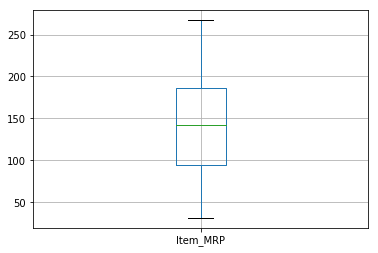

In [8]:
sales_df.boxplot(column = 'Item_MRP')

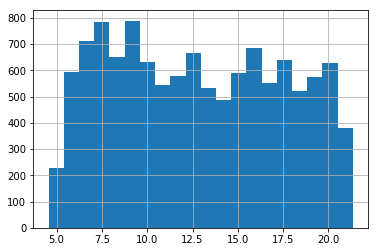

In [13]:
sales_df['Item_Weight'].hist(bins=20)

In [21]:
train_sales_df['Outlet_Location_Type'].value_counts(ascending = True)

Tier 1    2388
Tier 2    2785
Tier 3    3350
Name: Outlet_Location_Type, dtype: int64

In [19]:
sales_df.Outlet_Establishment_Year.unique().shape

(9,)

In [17]:
train_sales_df.loc[(train_sales_df['Item_Weight'].isnull() == True),['Item_Identifier']]

AttributeError: 'DataFrame' object has no attribute 'value_counts'

In [13]:
train_sales_df.pivot_table(index = null_weight['Item_Identifier'],aggfunc = np.mean)

,Item_MRP,Item_Outlet_Sales,Item_Visibility,Outlet_Establishment_Year
Item_Identifier,,,,
DRA24,164.5368,2702.4822,0.054822,1985
DRA59,186.4924,3794.3942,0.175647,1985
DRB01,190.0530,569.2590,0.081841,1985
DRB25,106.0938,2787.0388,0.069123,1985
DRB48,40.2822,1296.3126,0.024733,1985
DRC01,48.4692,1034.6532,0.019107,1985
DRC25,87.0882,730.0497,0.039720,1985
DRC36,173.7054,5778.4782,0.044767,1985
DRC49,145.7128,4026.7584,0.065120,1985
